<a href="https://colab.research.google.com/github/vanshika-tiwari123/5G-AI-Optimizer-/blob/main/5G_AI_Optimizer_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install "shimmy>=2.0"

In [22]:
!pip install numpy pandas scikit-learn matplotlib seaborn

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [24]:
np.random.seed(42)

n_samples = 2000

data = pd.DataFrame({
    'users': np.random.randint(10, 500, n_samples),
    'signal_strength': np.random.uniform(-110, -50, n_samples),
    'bandwidth': np.random.uniform(10, 100, n_samples),
    'interference': np.random.uniform(0, 1, n_samples),
    'network_load': np.random.uniform(0.1, 1.0, n_samples)
})

# Target variables (simulated realistic formulas)
data['throughput'] = (
    data['bandwidth'] * (1 - data['interference']) *
    (data['signal_strength'] + 120) / 70 *
    (1 - data['network_load'])
)

data['latency'] = (
    100 / data['bandwidth'] +
    data['network_load'] * 50 +
    data['interference'] * 30
)

data.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,users,signal_strength,bandwidth,interference,network_load,throughput,latency
0,112,-105.798218,59.464564,0.385554,0.345515,4.851624,30.524006
1,445,-109.430874,72.080096,0.506686,0.517196,2.592093,42.447733
2,358,-106.838970,22.954772,0.856001,0.899054,0.062735,74.989131
3,280,-104.687395,63.582370,0.749954,0.509612,1.705486,49.551964
4,116,-107.744194,25.489954,0.805117,0.600321,0.347615,58.092660


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


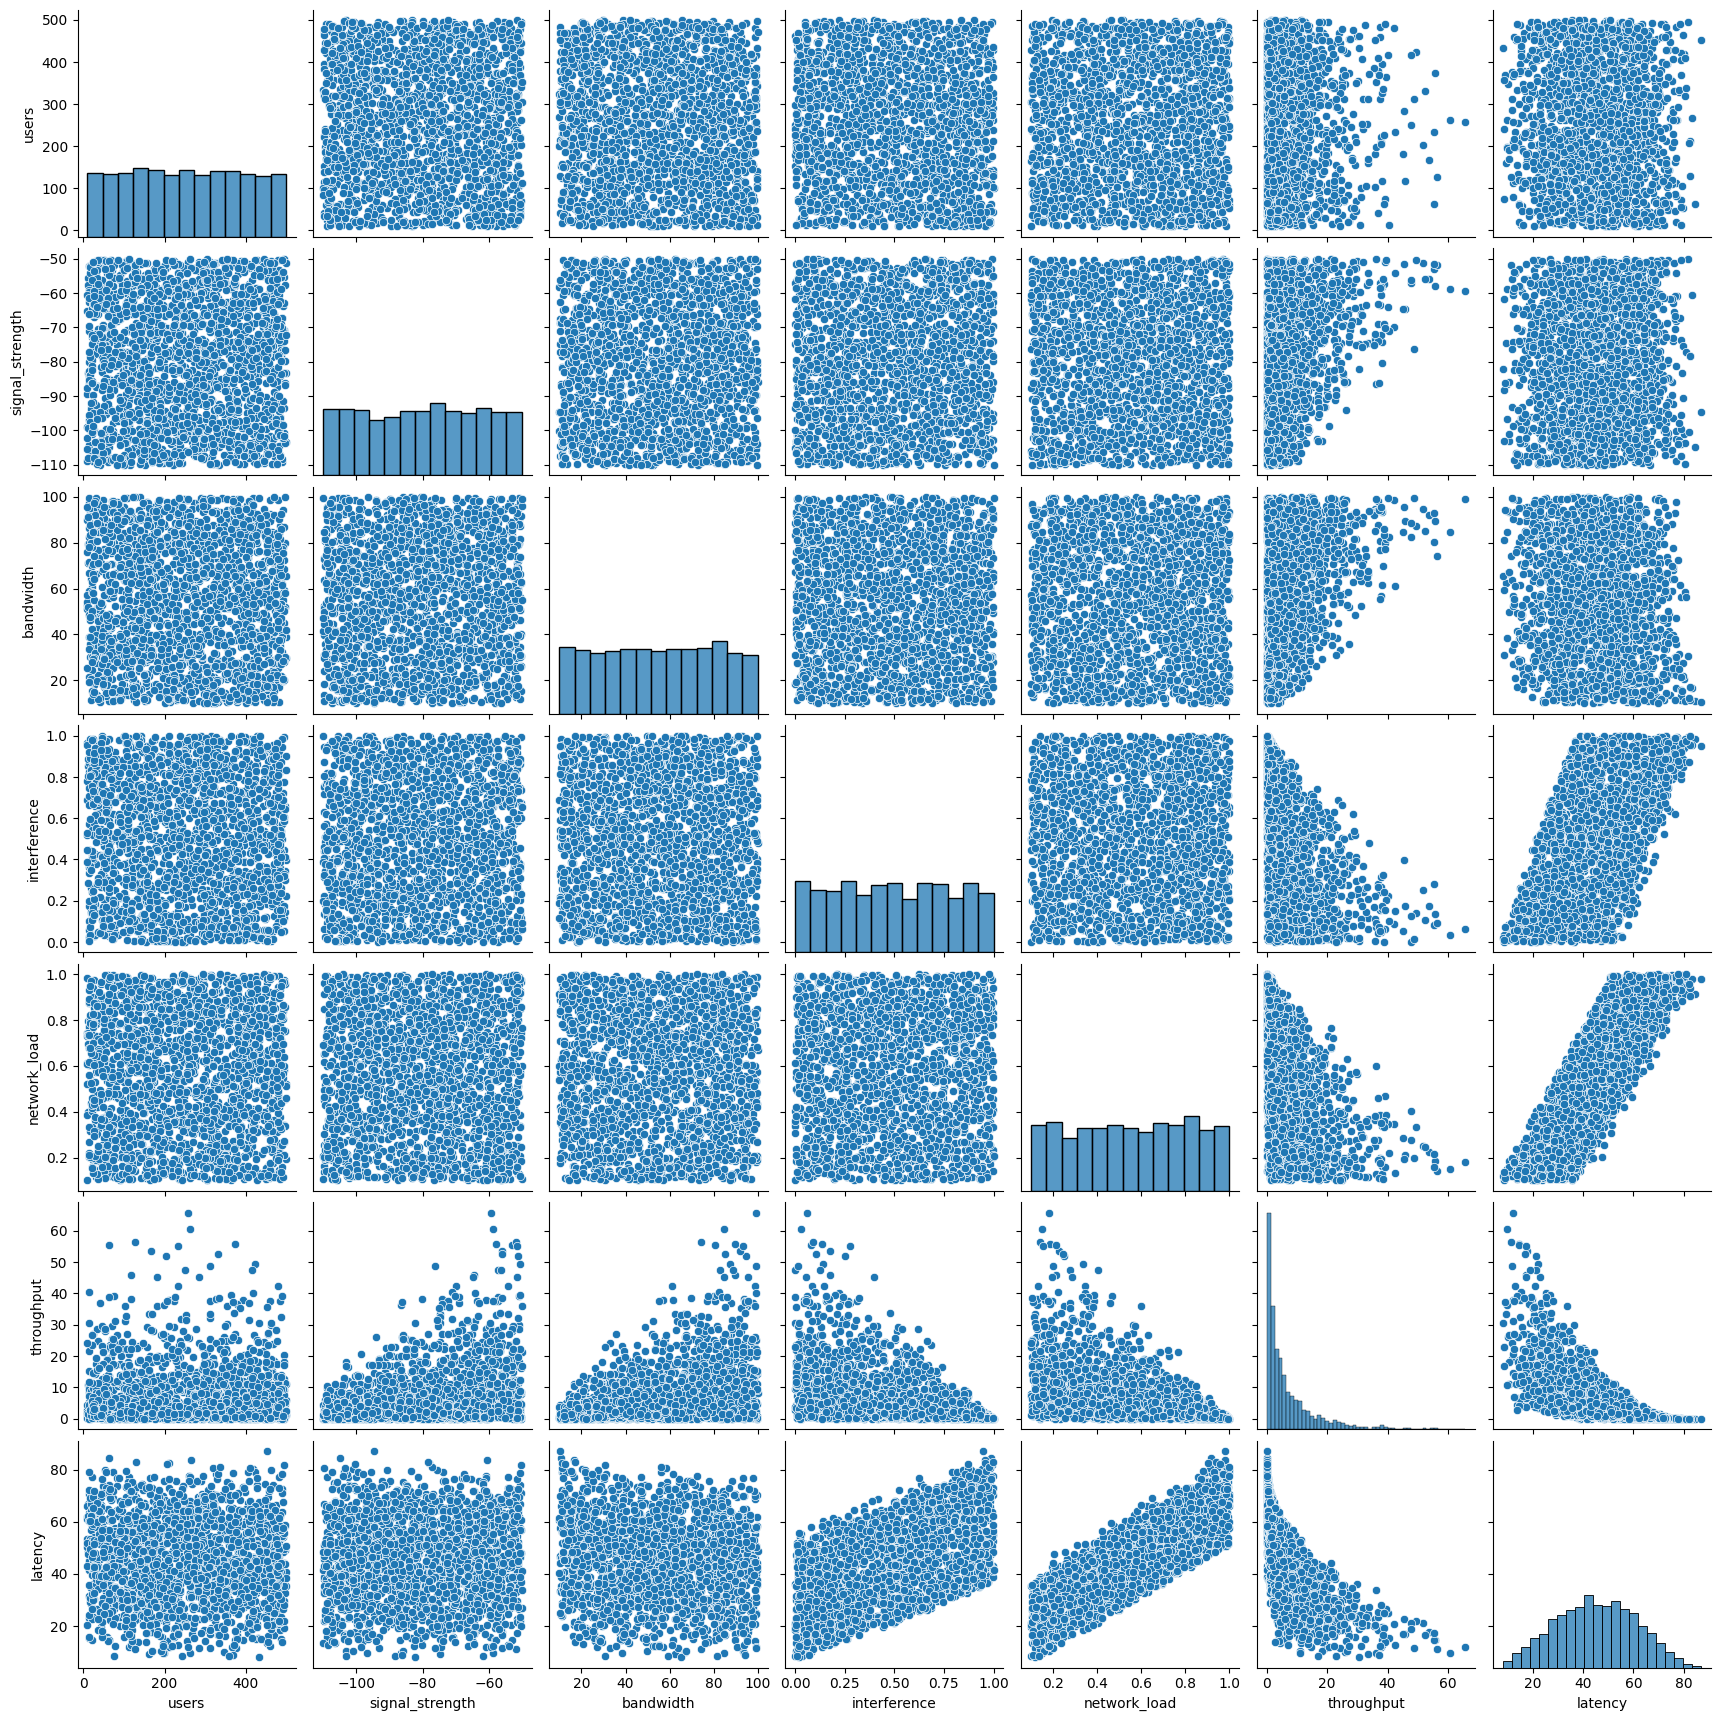

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
sns.pairplot(data)
plt.show()

In [26]:
X = data[['users', 'signal_strength', 'bandwidth', 'interference', 'network_load']]
y_throughput = data['throughput']
y_latency = data['latency']

X_train, X_test, y_t_train, y_t_test = train_test_split(X, y_throughput, test_size=0.2)
_, _, y_l_train, y_l_test = train_test_split(X, y_latency, test_size=0.2)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
# Throughput Model
model_throughput = RandomForestRegressor(n_estimators=100)
model_throughput.fit(X_train, y_t_train)

# Latency Model
model_latency = RandomForestRegressor(n_estimators=100)
model_latency.fit(X_train, y_l_train)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


RandomForestRegressor()

In [28]:
# Predictions
t_pred = model_throughput.predict(X_test)
l_pred = model_latency.predict(X_test)

# Metrics
print("Throughput MAE:", mean_absolute_error(y_t_test, t_pred))
print("Throughput R2:", r2_score(y_t_test, t_pred))

print("Latency MAE:", mean_absolute_error(y_l_test, l_pred))
print("Latency R2:", r2_score(y_l_test, l_pred))

Throughput MAE: 0.8359516442057767
Throughput R2: 0.9707207307715618
Latency MAE: 13.231600600326628
Latency R2: -0.03990377291299585


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
def optimize_network(users, signal_strength, interference):
    best_config = None
    best_score = -np.inf

    for bandwidth in np.linspace(10, 100, 20):
        for load in np.linspace(0.1, 1.0, 10):

            input_data = np.array([[users, signal_strength, bandwidth, interference, load]])

            throughput = model_throughput.predict(input_data)[0]
            latency = model_latency.predict(input_data)[0]

            score = throughput - latency  # optimization objective

            if score > best_score:
                best_score = score
                best_config = (bandwidth, load, throughput, latency)

    return best_config

In [30]:
result = optimize_network(
    users=200,
    signal_strength=-80,
    interference=0.3
)

print("Optimal Bandwidth:", result[0])
print("Optimal Load:", result[1])
print("Predicted Throughput:", result[2])
print("Predicted Latency:", result[3])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

Optimal Bandwidth: 66.84210526315789
Optimal Load: 0.1
Predicted Throughput: 23.78912417437291
Predicted Latency: 41.13260738557854


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return da

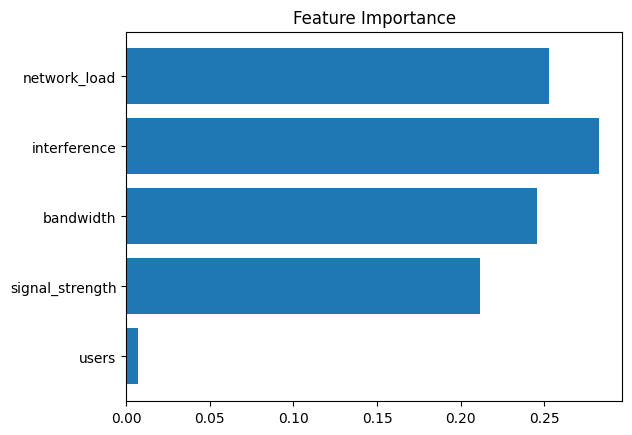

In [31]:
importance = model_throughput.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_t_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
import joblib

joblib.dump(model_throughput, 'throughput_model.pkl')
joblib.dump(model_latency, 'latency_model.pkl')

['latency_model.pkl']

REAL WORLD DATASET FROM KAGGLE


In [34]:
import pandas as pd

data = pd.read_csv('/content/qcom_summary.csv')
data.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ReportId,ReportTitle,ReportSubType,ReportYear,ReportDate,DocumentId,DocumentOrder,DocumentCategory,DocumentTitle,DocumentFileType,DocumentFileSize,DocumentPath,ThumbnailPath
0,2663,First Quarter 2015,First Quarter,2015,2014-12-28,7020,1,tenq,10-Q,PDF,537 KB,https://s204.q4cdn.com/645488518/files/doc_fin...,https://s204.q4cdn.com/645488518/files/doc_fin...
1,2663,First Quarter 2015,First Quarter,2015,2014-12-28,7536,35001,tenq,10-Q,NaN,NaN,https://d18rn0p25nwr6d.cloudfront.net/CIK-0000...,NaN
2,2663,First Quarter 2015,First Quarter,2015,2014-12-28,7378,80000,news,FY 2015 1st Quarter Earnings Release,PDF,750 KB,https://s204.q4cdn.com/645488518/files/doc_fin...,https://s204.q4cdn.com/645488518/files/doc_fin...
3,2663,First Quarter 2015,First Quarter,2015,2014-12-28,7379,90000,presentation,Executive Presentation,PDF,306 KB,https://s204.q4cdn.com/645488518/files/doc_fin...,https://s204.q4cdn.com/645488518/files/doc_fin...
4,2663,First Quarter 2015,First Quarter,2015,2014-12-28,7375,100000,other,3G/4G Device Estimates,PDF,69 KB,https://s204.q4cdn.com/645488518/files/doc_fin...,https://s204.q4cdn.com/645488518/files/doc_fin...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
!pip install stable-baselines3 gym

In [36]:
import gym
from gym import spaces
import numpy as np

class NetworkEnv(gym.Env):
    def __init__(self):
        super(NetworkEnv, self).__init__()

        self.action_space = spaces.Box(low=np.array([10, 0.1]),
                                       high=np.array([100, 1.0]),
                                       dtype=np.float32)

        self.observation_space = spaces.Box(low=0, high=1, shape=(5,), dtype=np.float32)

    def step(self, action):
        bandwidth, load = action

        users = np.random.randint(50, 300)
        signal = np.random.uniform(-100, -60)
        interference = np.random.uniform(0, 1)

        throughput = bandwidth * (1 - interference) * (signal + 120)/60
        latency = 100/bandwidth + load*50

        reward = throughput - latency

        state = np.array([users/500, signal/120, bandwidth/100, interference, load])

        return state, reward, False, {}

    def reset(self):
        return np.random.rand(5)

In [37]:
from stable_baselines3 import PPO

env = NetworkEnv()
model = PPO("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=10000)

/usr/local/lib/python3.12/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 794  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| time/                   |            |
|    fps                  | 718        |
|    iterations           | 2          |
|    time_elapsed         | 5          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01620407 |
|    clip_fraction        | 0.179      |
|    clip_range           | 0.2        |
|    entropy_loss         | -2.82      |
|    explained_variance   | 2.62e-05   |
|    learning_rate        | 0.0003     |
|    loss                 | 7.71e+04   |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0278    |
|    std                  | 0.981      |
|    value_loss           | 1.65e+05   |
----------------------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 767        |
|    iterations           | 3          |
|    time_elapsed         | 8          |
|    total_times

In [38]:
def step(self, action):
    bandwidth, load = action

    users = np.random.randint(50, 300)
    signal = np.random.uniform(-100, -60)
    interference = np.random.uniform(0, 1)

    throughput = bandwidth * (1 - interference) * (signal + 120)/60
    latency = 100/bandwidth + load*50

    reward = throughput - latency

    state = np.array([users/500, signal/120, bandwidth/100, interference, load])

    terminated = False
    truncated = False

    return state, reward, terminated, truncated, {}

In [39]:

def reset(self, seed=None, options=None):
    return np.random.rand(5), {}

In [40]:
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 887  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 823         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.017613765 |
|    clip_fraction        | 0.206       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.82       |
|    explained_variance   | -0.00014    |
|    learning_rate        | 0.0003      |
|    loss                 | 7.89e+04    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0312     |
|    std                  | 0.98        |
|    value_loss           | 1.67e+05    |
----------------------------------

In [41]:
obs = env.reset()

for _ in range(5):
    action, _ = model.predict(obs)
    obs, reward, done, _ = env.step(action)
    print("Optimized Action:", action, "Reward:", reward)

Optimized Action: [10.          0.14417383] Reward: -13.789537
Optimized Action: [10.   0.1] Reward: -13.984205
Optimized Action: [10.   0.1] Reward: -11.216259
Optimized Action: [10.          0.21261579] Reward: -18.991407
Optimized Action: [10.   0.1] Reward: -13.067511


In [42]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.2 MB/s eta 0:00:00


In [43]:
import streamlit as st
import joblib
import numpy as np

model_t = joblib.load('throughput_model.pkl')
model_l = joblib.load('latency_model.pkl')

st.title("5G AI Optimizer")

users = st.slider("Users", 10, 500)
signal = st.slider("Signal Strength", -110, -50)
interference = st.slider("Interference", 0.0, 1.0)

bandwidth = st.slider("Bandwidth", 10, 100)
load = st.slider("Network Load", 0.1, 1.0)

input_data = np.array([[users, signal, bandwidth, interference, load]])

throughput = model_t.predict(input_data)[0]
latency = model_l.predict(input_data)[0]

st.write("Throughput:", throughput)
st.write("Latency:", latency)

2026-03-17 11:43:27.204 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 11:43:27.837 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-17 11:43:27.844 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 11:43:27.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 11:43:27.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 11:43:27.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 11:43:27.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 11:43:27.862 Thread 'MainThread': mi

In [47]:
%%writefile app.py
import streamlit as st
import numpy as np

st.title("5G AI Optimizer")

users = st.slider("Users", 10, 500)
signal = st.slider("Signal Strength", -110, -50)
interference = st.slider("Interference", 0.0, 1.0)

bandwidth = st.slider("Bandwidth", 10, 100)
load = st.slider("Network Load", 0.1, 1.0)

# Simple formula (demo)
throughput = bandwidth * (1 - interference) * (signal + 120)/60
latency = 100/bandwidth + load*50

st.write("Throughput:", throughput)
st.write("Latency:", latency)

Writing app.py


In [48]:
!pip install streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 2s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [49]:
!streamlit run app.py &>/dev/null &

In [55]:
!npx localtunnel --port 8501


⠙⠹⠸^C


In [53]:
!curl ifconfig.me

34.60.68.151

In [56]:
!pip install streamlit pyngrok
!apt install cloudflared

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package cloudflared


In [57]:
!streamlit run app.py &>/dev/null &

In [58]:
!cloudflared tunnel --url http://localhost:8501

/bin/bash: line 1: cloudflared: command not found


In [59]:
!cloudflared tunnel --url http://localhost:8501

/bin/bash: line 1: cloudflared: command not found
